# Gene-driven Perturbation (GNP) Overexpression Simulation

This tutorial demonstrates how to use the GNP (Gene Network Perturbation) module to perform an in silico gene overexpression (OE) analysis on mouse Stereo-seq spatial transcriptomics data.

⸻

1. Dataset Overview

We utilize high-resolution spatial transcriptomics data from the Ma2024 dataset:

Study
Spatial transcriptomic landscape unveils immunoglobulin-associated senescence as a hallmark of aging
Ma, Shuai et al., Cell, 2024

Biological Context
This dataset captures the    spatial organization of transcriptional programs associated with brain aging in mice.
In this tutorial, we focus on simulating gene overexpression in a targeted cell population to investigate how elevated gene activity may reshape local cellular niches and aging-associated spatial patterns.

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad
import seaborn as sns
from typing import Optional
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import sys
sys.path.append("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon_v2/BrainBeacon/")
from brainbeacon.pipeline.cell_embedding import run_bbcellformer_pipeline
from brainbeacon.pipeline.perturbation import apply_gene_perturbation, inject_cells_into_niche, plot_global_euclidean_shift
from brainbeacon.pipeline.perturbation import analyze_embedding_similarity_change, plot_cosine_to_centroids_with_perturb_OE
from brainbeacon.pipeline.perturbation import analyze_embedding_similarity_change_similarity_niche_OE, analyze_embedding_similarity_change_OE
from brainbeacon.utils import set_seed
import brainbeacon.configs.config as cfg
from brainbeacon.configs.config_train import config_train as cfg_train
from brainbeacon.utils import compute_density_token, compute_deviation_bin_rapid_v2
from brainbeacon.utils import convert_spatial_to_um, platform_radius_map
import logging
logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig4_subfig_OE"
os.makedirs(out_fig_dir, exist_ok=True)

Using device: cuda
Using GPU: NVIDIA H800


In [3]:
# =============================================================================
# 1. Dataset and Basic Setup
# =============================================================================
dataset_name = "ma2024aging_cell2niche_niche_inneroe"
specie = "mouse"  # NOTE: keep original variable name for compatibility
assay = "stereo"

# =============================================================================
# 2. Prior Knowledge / Paths
# =============================================================================
# Base directories
BASE_DIR = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/")

# Sync into cfg (assumes cfg / cfg_train already exist in your notebook/runtime)
cfg.DEFAULT_PATHS["BASE_DIR"] = str(BASE_DIR)
cfg.DEFAULT_PATHS["PRETRAIN_DIR"] = "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/"
cfg.DEFAULT_PATHS["PRIOR_DIR"] = cfg.DEFAULT_PATHS["PRETRAIN_DIR"]
cfg.DEFAULT_PATHS["GENE_DICT_PATH"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/model_h5ad_1211.h5ad"
)

# Path to the processed AnnData object used in this tutorial.
# The processed file (adata_outer_ensembl.h5ad) can be downloaded directly from:
# https://drive.google.com/file/d/1-z8J8xiRN0qD0preVQr8cAHKQXuScBp2/view?usp=drive_link
#
# Alternatively, the original raw Stereo-seq data can be obtained from the CNGBdb STOmics portal:
# https://db.cngb.org/stomics/datasets/STDS0000247/data
# Users may start from the raw data and follow their own preprocessing pipeline if desired.
adata_path = BASE_DIR / "data" / "adata_outer_ensembl.h5ad"  # adata_outer_ensembl / adata_inner_ensembl

gene_dict_path = Path(cfg.DEFAULT_PATHS["GENE_DICT_PATH"])
gene_mean_path = Path(
    "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"
)

# ESM embedding path
cfg_train["esm_embedding_path"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/esm2_embeddings_d5120.pt"
)

# Basic sanity checks (fail fast)
assert adata_path.exists(), f"adata_path not found: {adata_path}"
assert gene_dict_path.exists(), f"gene_dict_path not found: {gene_dict_path}"
assert gene_mean_path.exists(), f"gene_mean_path not found: {gene_mean_path}"
assert Path(cfg_train["esm_embedding_path"]).exists(), f"esm_embedding_path not found: {cfg_train['esm_embedding_path']}"

# =============================================================================
# 3. Pretrained Checkpoints
# =============================================================================
pretrain_dir = BASE_DIR / "pretrained"

bb_ckpt_name = "epoch_0_setp_800000.pt"
cellformer_ckpt_name = "cellformer_epoch99.pt"  # trained on all ma2024aging data
# cellformer_ckpt_name = "cellformer.ckpt"      # CellPLM original checkpoint

bb_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt")
cellplm_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt")

assert bb_ckpt_path.exists(), f"bb_ckpt_path not found: {bb_ckpt_path}"
assert cellplm_ckpt_path.exists(), f"cellplm_ckpt_path not found: {cellplm_ckpt_path}"

# =============================================================================
# 4. Output Naming
# =============================================================================
cd_weight = 0.02
use_hvg = True
n_hvg = 5000

bb_ckpt_tag = bb_ckpt_name.replace(".pt", "").replace(".ckpt", "")
if use_hvg:
    method_name = f"bbcellformer_{bb_ckpt_tag}_hvg{n_hvg}_cd{cd_weight}"
else:
    method_name = f"bbcellformer_{bb_ckpt_tag}_cd{cd_weight}"

output_dir = BASE_DIR / "downstream_tasks" / "virtual_perturbation" / "outputs" / dataset_name / method_name
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 5. Load Data and (Optionally) Select Slices
# =============================================================================
full_adata = sc.read_h5ad(str(adata_path))

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]

# NOTE: Uncomment if you want to restrict to selected slices
# adata = full_adata[full_adata.obs["slice"].isin(selected_slices)].copy()
adata = full_adata.copy()

# =============================================================================
# 6. Derive Labels
# =============================================================================
def infer_cell_label(slice_name: str) -> Optional[str]:
    """Infer 'Young' / 'Old' from slice naming convention."""
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    if slice_name.startswith("Hippocampus_O"):
        return "Old"
    return None  # Unknown slice pattern

# Apply label + batch
adata.obs["cell_label"] = adata.obs["slice"].astype(str).map(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]

# Enforce categorical type (keeps only 'Young' and 'Old' as known categories)
adata.obs["cell_label"] = pd.Categorical(adata.obs["cell_label"], categories=["Young", "Old"])

In [4]:
DEG_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/1-s2.0-S0092867424012017-mmc2.xlsx" 
#download from supplementary materials of Ma et al., Cell, 2024
DEG_df = pd.read_excel(DEG_path, sheet_name="Hippocampus", skiprows=1)
n_unique_genes = DEG_df["Gene"].str.upper().nunique()
print("Unique gene count:", n_unique_genes)

Unique gene count: 2628


Next, we select regions of interest (ROIs) to further investigate
how the perturbation reshapes local cellular niches after gene perturbation.
These ROIs enable a focused analysis of spatial and niche-level changes
induced by the perturbation.

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


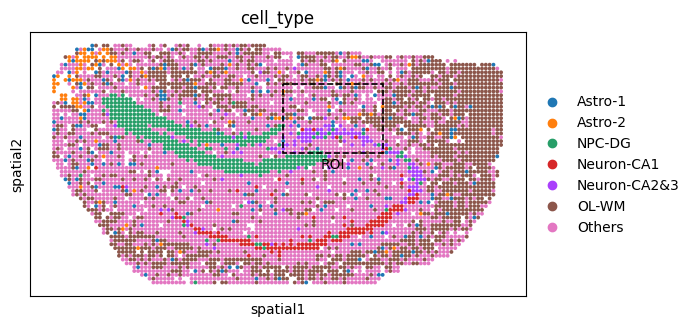

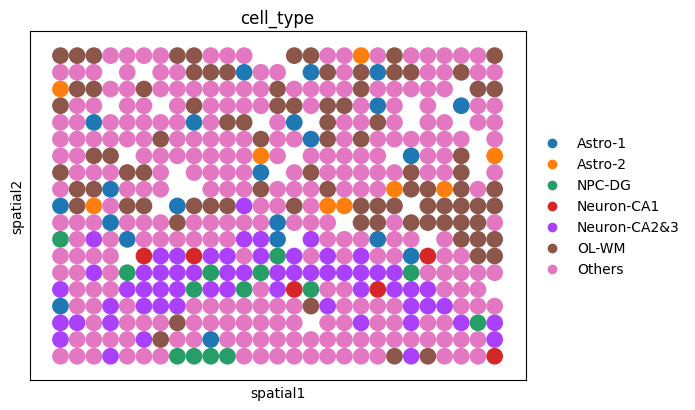

In [5]:
ol_cells = adata[adata.obs["slice"] == "Hippocampus_O_2_1"].copy()
ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &    
    (ol_cells.obsm["spatial"][:, 1] > 10) &    
    (ol_cells.obsm["spatial"][:, 0] < 88) &      
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
ol_cells.obs["cell_type"] = ol_cells.obs["cell_type"].astype("category")
categories = ol_cells.obs["cell_type"].cat.categories
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"], categories=categories, ordered=True
)

ol_cells.uns["cell_type_colors"] = ol_cells.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(categories)]
)
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

roi_coords = ol_roi.obsm["spatial"]
xmin, xmax = roi_coords[:, 0].min(), roi_coords[:, 0].max()
ymin, ymax = roi_coords[:, 1].min(), roi_coords[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2
os.makedirs(out_fig_dir, exist_ok=True)

fig_ol = sc.pl.spatial(
    ol_cells, color="cell_type", spot_size=1, show=False, return_fig=True
)
ax_ol = fig_ol.axes[0]
rect = Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--'
)
ax_ol.add_patch(rect)

ax_ol.text(
    xcenter, ymax + 5, "ROI",
    color='black', fontsize=10, ha='center', va='bottom'
)
fig_roi = sc.pl.spatial(
    ol_roi, color="cell_type", spot_size=1, show=False, return_fig=True
)

x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


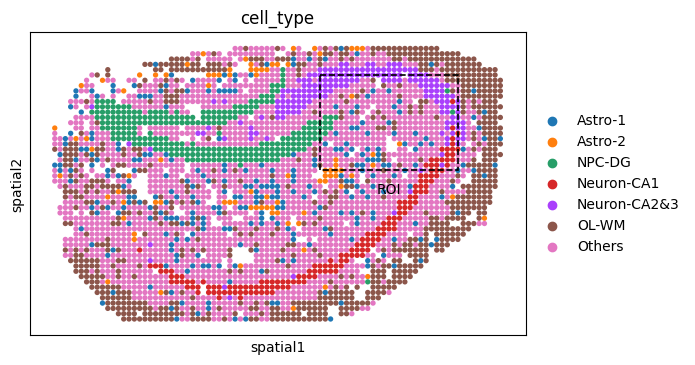

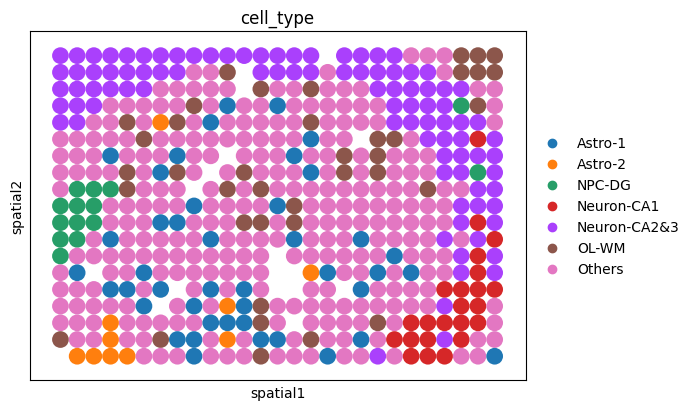

In [6]:
# === Matplotlib settings (ensure editable text in PDF/SVG) ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Ensure output directory ===
os.makedirs(out_fig_dir, exist_ok=True)

# === Step 1: subset slice ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: coordinates ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: ROI bounds (x in (60, 88), y in (10, 30)) ===
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.n_obs}")

# === Step 4: sync categories & colors ===
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
cats = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=cats, ordered=True)

adata_Y.uns["cell_type_colors"] = adata_Y.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(cats)]
)
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5a: full view with ROI box ===
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)

# Add dashed ROI box
roi_xy = y_roi.obsm["spatial"]
xmin, xmax = roi_xy[:, 0].min(), roi_xy[:, 0].max()
ymin, ymax = roi_xy[:, 1].min(), roi_xy[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2

ax = fig1.axes[0]
rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(xcenter, ymax + 5, "ROI", color='black', fontsize=10, ha='center', va='bottom')
# === Step 5b: ROI-only ===
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)

In [7]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [8]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad


In [9]:
# ========== 6. Run Original Inference ==========
# This step constructs the baseline (unperturbed) reference by running inference
# on the original data, which serves as the control condition for all subsequent
# perturbation analyses.
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=True,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")


Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.0038387576738993325 min


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.38s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.13 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:11<00:00,  1.38it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
Time cost:  0.3175329407056173
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.


...

Epoch 98 | Train loss: 6803.6355 | Valid loss: 6843.8608


100%|██████████| 100/100 [00:59<00:00,  1.67it/s]

Epoch 99 | Train loss: 6832.2544 | Valid loss: 6840.0640
After filtering, 20316 genes remain.



... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_reg

In [10]:
# =============================================================================
# Perturbation module: in silico gene overexpression (OE)
# =============================================================================
# This module performs an in silico perturbation by overexpressing a target gene
# in a specified cell population.
#
# In this example, we simulate overexpression of Igkc in OL-WM cells from the
# young mouse hippocampus slice ("Hippocampus_Y_2_1").
#
# The overexpression value is explicitly set to 60, meaning that the expression
# of Igkc in the selected cells will be overwritten to this fixed value.
#
# Notes:
# - You may change `value` to test different absolute expression levels.
# - Alternatively, you can set `multiplier` instead of `value` to scale gene
#   expression relative to its original magnitude.
# - You may also omit `filter_by` or the `cell_type` field to apply overexpression
#   to all cells within a slice, or even across the entire dataset.

perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list=["Igkc"],                 # Target gene(s) to perturb (can be multiple genes)
    mode="overexpress",                 # Perturbation mode: overexpression (OE)
    filter_by={
        "slice": "Hippocampus_Y_2_1",   # Target slice (young mouse)
        "cell_type": "OL-WM",           # Target cell type (set to None to affect all cell types)
    },
    value=60,                           # Fixed overexpression value
    # multiplier=2,                     # Optional: scale expression by a factor instead of fixed value
)
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 60.")

# Save perturbed input AnnData
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# =============================================================================
# 8. Run perturbation inference
# =============================================================================
# The perturbed AnnData is passed through the pretrained BrainBeacon + CellFormer
# pipeline to reconstruct embeddings under the perturbed gene expression state.

cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_final = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device,
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_final)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_final.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# =============================================================================
# Analyze embedding similarity change
# =============================================================================
# After perturbation, we compare embedding similarity between:
#   - young vs old target cells
#   - young vs old target-cell niches
# to quantify how Igkc overexpression shifts cellular and niche-level states.

target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

Perturbed 39 cells: set expression of target gene(s) to 60.
Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.0038858334223429362 min


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.04 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:11<00:00,  1.36it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
Time cost:  0.29859442710876466
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filter

... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'ba

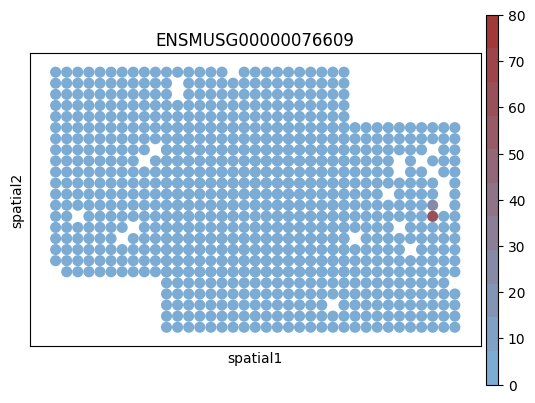

In [11]:
# This plot visualizes the spatial expression of Igkc (ENSMUSG00000076609)
# in both young and old mouse hippocampal ROIs, highlighting baseline
# differences in Igkc expression across aging conditions.

custom_colors = ["#7CACD4", "#A13939"]  # blue → red
cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=10 + 1)

sc.pl.spatial(
    adata_fov_OL,
    color="ENSMUSG00000076609",  # Igkc
    spot_size=1,
    cmap=cmap,
    vmax=80,
    show=False,
)

# Ensure editable text in vector formats
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig = plt.gcf()  # get current figure

Text(0.5, 0.98, 'Spatial expression of Igkc after overexpression in the specified target cell type')

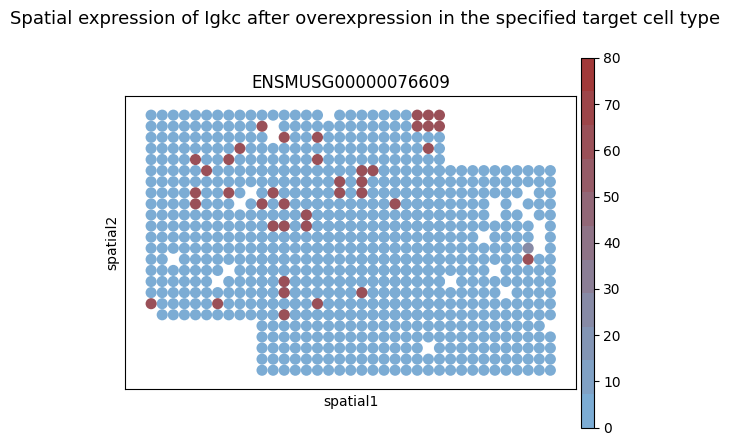

In [12]:
# This plot shows the spatial expression of Igkc (ENSMUSG00000076609)
# after gene overexpression (OE), highlighting how Igkc expression
# is distributed once the perturbation is applied to a specified
# target cell type (e.g., OL-WM cells).

# draw but do not show
custom_colors = ["#7CACD4", "#A13939"]  # blue → red
cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=10 + 1)

sc.pl.spatial(
    perturbed_adata_final,
    color="ENSMUSG00000076609",  # Igkc
    spot_size=1,
    cmap=cmap,
    vmax=80,
    show=False,                 # keep figure in memory
)

# Ensure editable text in vector formats
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig = plt.gcf()  # get current figure
fig.suptitle(
    "Spatial expression of Igkc after overexpression in the specified target cell type",
    fontsize=13,
    y=0.98,
)

In [13]:
# This block evaluates the effect of Igkc overexpression (OE) in young target cells.
# Specifically, it compares embedding similarity between:
#   (i) young vs old target cells before and after OE (cell-intrinsic effect), and
#   (ii) young target-cell niches vs old-cell niches before and after OE (niche-level effect).
# Metrics include cosine similarity, Euclidean distance, Wasserstein distance (EMD), and MMD.

# =============================================================================
# Cell-intrinsic similarity: target young cells vs old cells (before / after OE)
# =============================================================================
result_cell = analyze_embedding_similarity_change_OE(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb",
)

cell_cosine_before, cell_cosine_after = result_cell["cosine"]
cell_euclid_before, cell_euclid_after = result_cell["euclidean"]
cell_emd_before, cell_emd_after = result_cell["emd"]
cell_mmd_before, cell_mmd_after = result_cell["mmd"]

print("Target cell (Young → Old) similarity after Igkc OE:")
print("  Cosine similarity        : before = {:.4f}, after = {:.4f}".format(cell_cosine_before, cell_cosine_after))
print("  Euclidean distance       : before = {:.4f}, after = {:.4f}".format(cell_euclid_before, cell_euclid_after))
print("  Wasserstein distance (EMD): before = {:.4f}, after = {:.4f}".format(cell_emd_before, cell_emd_after))
print("  MMD                      : before = {:.4f}, after = {:.4f}".format(cell_mmd_before, cell_mmd_after))

# =============================================================================
# 2. Niche-level similarity: young target-cell niche vs old-cell niche (before / after OE)
# =============================================================================
result_niche = analyze_embedding_similarity_change_similarity_niche_OE(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb",
)

niche_cosine_before, niche_cosine_after = result_niche["cosine"]
niche_euclid_before, niche_euclid_after = result_niche["euclidean"]
niche_emd_before, niche_emd_after = result_niche["emd"]
niche_mmd_before, niche_mmd_after = result_niche["mmd"]

print("\nTarget cell niche (Young → Old) similarity after Igkc OE:")
print("  Cosine similarity        : before = {:.4f}, after = {:.4f}".format(niche_cosine_before, niche_cosine_after))
print("  Euclidean distance       : before = {:.4f}, after = {:.4f}".format(niche_euclid_before, niche_euclid_after))
print("  Wasserstein distance (EMD): before = {:.4f}, after = {:.4f}".format(niche_emd_before, niche_emd_after))
print("  MMD                      : before = {:.4f}, after = {:.4f}".format(niche_mmd_before, niche_mmd_after))

Target cell (Young → Old) similarity after Igkc OE:
  Cosine similarity        : before = 0.1655, after = 0.1792
  Euclidean distance       : before = 12.0616, after = 11.8573
  Wasserstein distance (EMD): before = 0.3415, after = 0.3398
  MMD                      : before = 0.0370, after = 0.0370

Target cell niche (Young → Old) similarity after Igkc OE:
  Cosine similarity        : before = 0.1066, after = 0.1100
  Euclidean distance       : before = 13.1777, after = 13.1947
  Wasserstein distance (EMD): before = 0.3707, after = 0.3711
  MMD                      : before = 0.0050, after = 0.0050


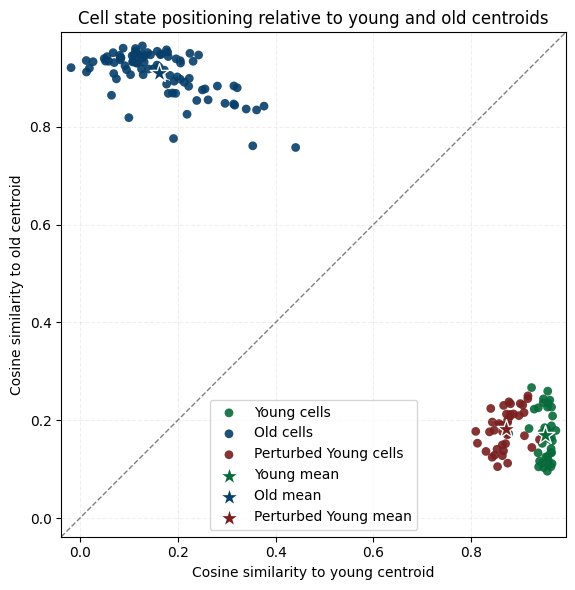

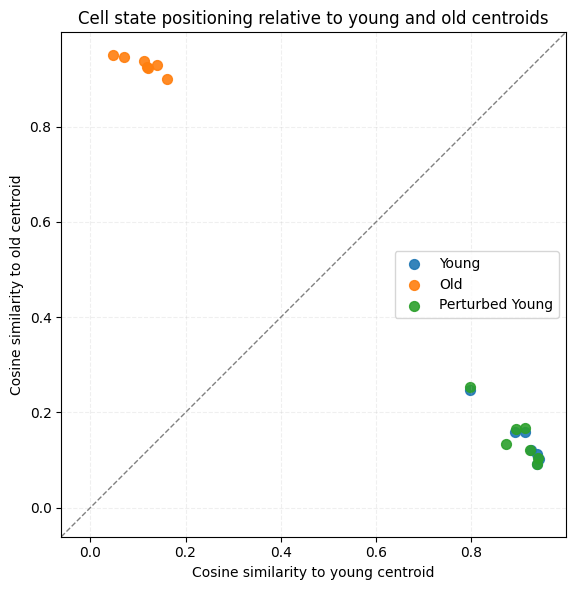

In [14]:
plot_cosine_to_centroids_with_perturb_OE(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=True,
    # save_path=os.path.join(f"{out_fig_dir}/target_cell_cell_stat_Igkc.pdf")
)

# # 只分析 niche-only
plot_cosine_to_centroids_with_perturb_OE(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=False,
    agg_by_celltype=True,
    # save_path=os.path.join(f"{out_fig_dir}/niche_cell_cell_stat.pdf")
)

In [15]:
# =============================================================================
# Perturbation example: Igkc overexpression in young cells (all cell types)
# =============================================================================
# This example demonstrates an in silico overexpression (OE) perturbation
# where Igkc is overexpressed in ALL cells from a young mouse hippocampal slice,
# without restricting to a specific cell type.
#
# Compared with cell-type–specific perturbation, this setting allows users to
# investigate the global effect of Igkc overexpression on the tissue context,
# including both cell-intrinsic responses and indirect niche-level changes.
#
# Key points:
# - Only the slice is specified ("Hippocampus_Y_2_1")
# - No cell_type constraint is applied
# - All cells within the selected slice are perturbed
# - Igkc expression is set to a fixed value (60) in the selected cells
#
# Users may alternatively:
# - Specify `cell_type` in `filter_by` to restrict perturbation to a subset of cells
# - Use `multiplier` instead of `value` to scale expression relative to baseline

perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list=["Igkc"],                  # Target gene to overexpress
    mode="overexpress",                  # Overexpression (OE) mode
    filter_by={
        "slice": "Hippocampus_Y_2_1",    # Apply to all cells in the young slice
        # "cell_type": "OL-WM",          # (Optional) restrict to a specific cell type
    },
    value=60,                            # Fixed overexpression value
)
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 60.")

# Save perturbed input AnnData
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# =============================================================================
# 8. Run perturbation inference
# =============================================================================
# The perturbed AnnData is passed through the pretrained BrainBeacon + CellFormer
# pipeline to obtain reconstructed embeddings under the overexpression condition.

cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_allcelltype = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device,
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_allcelltype)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_allcelltype.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# =============================================================================
# 9. Analyze embedding similarity change
# =============================================================================
# Downstream analysis typically compares:
#   - young vs old cells before and after perturbation
#   - cell-level vs niche-level embedding shifts
# to quantify how global Igkc overexpression reshapes aging-associated states.

target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

Perturbed 495 cells: set expression of target gene(s) to 60.
Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.003885956605275472 min


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.04 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:11<00:00,  1.41it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
Time cost:  0.2884314298629761
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filteri

... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'ba

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_global_euclidean_shift(
    adata_ori,
    adata_perturb,
    emb_key="X_emb",
    title="Perturbation-Induced Changes in Euclidean Distance to Global Reference",
    cmap="RdBu_r",
    save_path=None
):
    # ====== get embedding ======
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()

    X_perturb = adata_perturb.obsm[emb_key]
    if hasattr(X_perturb, "toarray"):
        X_perturb = X_perturb.toarray()

    global_centroid = X_ori.mean(axis=0, keepdims=True)

    # ====== cal euc ======
    dist_before = np.linalg.norm(X_ori - global_centroid, axis=1)
    dist_after = np.linalg.norm(X_perturb - global_centroid, axis=1)

    # ====== KDE  Plot ======
    plt.figure(figsize=(7, 6))
    sns.kdeplot(
        x=dist_before,
        y=dist_after,
        fill=True,
        cmap=cmap,
        bw_adjust=0.8,
        thresh=0.02,
        levels=60
    )

    min_val = min(dist_before.min(), dist_after.min())
    max_val = max(dist_before.max(), dist_after.max())
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', lw=1.2)
    plt.xlabel("Euclidean Distance to Global Centroid (Before Perturbation)", fontsize=12)
    plt.ylabel("Euclidean Distance to Global Centroid (After Perturbation)", fontsize=12)
    plt.title(title, fontsize=13, pad=10)
    plt.grid(alpha=0.2, lw=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=500)
        plt.close()
    else:
        plt.show()

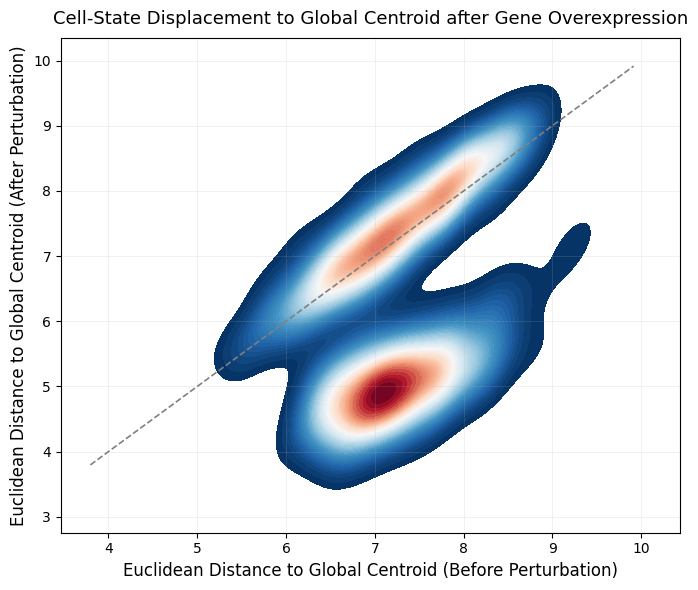

In [17]:

plot_global_euclidean_shift(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_allcelltype,
    title="Cell-State Displacement to Global Centroid after Gene Overexpression",
    # save_path="figures/Fig4d_Global_Euclidean_Shift.pdf"
)